# Final Year Project:

## Forecasting Policyholder Retention in Motor Insurance using Generalised Linear Models and Random Forests

### Author: Saanya Singh
#### Submitted: April 2026

In [1]:
## Loading required libraries 
import pandas as pd
import numpy as np
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, brier_score_loss, confusion_matrix, ConfusionMatrixDisplay, 
                             classification_report, balanced_accuracy_score, roc_curve)
from sklearn.calibration import calibration_curve

from sklearn.ensemble import RandomForestClassifier

In [2]:
# Fixed random seed to ensure reproducibility
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

## Data Preparation

In [3]:
# Load raw data
pols = pd.read_csv("freMTPL2freq.csv")
claims = pd.read_csv("freMTPL2sev.csv")

#### Data exploration

In [4]:
pols.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


In [5]:
pols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   VehPower    678013 non-null  int64  
 4   VehAge      678013 non-null  int64  
 5   DrivAge     678013 non-null  int64  
 6   BonusMalus  678013 non-null  int64  
 7   VehBrand    678013 non-null  object 
 8   VehGas      678013 non-null  object 
 9   Area        678013 non-null  object 
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  object 
dtypes: float64(2), int64(6), object(4)
memory usage: 62.1+ MB


In [6]:
claims.head()

,IDpol,ClaimAmount
0,1552,995.20
1,1010996,1128.12
2,4024277,1851.11
3,4007252,1204.00
4,4046424,1204.00


In [7]:
claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26639 entries, 0 to 26638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26639 non-null  int64  
 1   ClaimAmount  26639 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 416.4 KB


In [8]:
# Exploratory summaries

#pols.describe()
#pols.VehGas.value_counts()
#pols.Region.value_counts()
#pols.Area.value_counts()
#claims.ClaimAmount.describe()

#### Data aggregation

In [9]:
# Aggregating the claims dataset by policy ID to ensure only one row per policy ID despite multiple claims
claims_agg = (
    claims.groupby("IDpol")
       .agg(
           num_claims=("ClaimAmount", "count"),
           total_claim_amount=("ClaimAmount", "sum"),
           avg_claim_amount=("ClaimAmount", "mean")
       )
       .reset_index()
)

claims_agg.head()

,IDpol,num_claims,total_claim_amount,avg_claim_amount
0,139,1,303.00,303.00
1,190,1,1981.84,1981.84
2,414,1,1456.55,1456.55
3,424,2,10834.00,5417.00
4,463,1,3986.67,3986.67


In [10]:
# Merges freMTPL2freq and freMTPL2sev
merged = pols.merge(claims_agg, on="IDpol", how="left")
merged.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,num_claims,total_claim_amount,avg_claim_amount
0,1.0,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,NaN,NaN,NaN
1,3.0,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,NaN,NaN,NaN
2,5.0,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,NaN,NaN,NaN
3,10.0,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,NaN,NaN,NaN
4,11.0,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,NaN,NaN,NaN


#### Creating engineered variables

In [11]:
# Creates engineered variable columns
merged[["num_claims", "total_claim_amount", "avg_claim_amount"]] = (
    merged[["num_claims", "total_claim_amount", "avg_claim_amount"]]
    .fillna(0)
)

In [12]:
# Assigns a 1 if this policy has made a claim
merged["has_claimed"] = (merged["num_claims"] > 0).astype(int)

In [13]:
# Calculate policy exposure, avoid dividing by 0
merged["claim_frequency"] = merged["num_claims"] / merged["Exposure"].replace(0, 1)

In [14]:
# Exploratory summaries

#merged.info()
#merged[["num_claims", "total_claim_amount", "has_claimed", "claim_frequency"]].describe()
#merged["has_claimed"].value_counts()

In [15]:
# Calculates proportion of policies that have made a claim
prop_of_claims = claims["IDpol"].nunique() / len(pols)
print("Proportion of policies with a claims history: ", prop_of_claims * 100)

Proportion of policies with a claims history:  3.6798704449619697


In [16]:
# Saves agregated and merged dataset
merged.to_csv("merged_data.csv", index=False)

### Simulating renewal

In [17]:
# Reads the merged dataset
merged = pd.read_csv("merged_data.csv")

In [18]:
# Caps number of claims at 3
num_claims = merged["num_claims"].clip(upper=3)

In [19]:
# Transformation of variables
log_claim_cost_k = np.log1p(merged["total_claim_amount"] / 1000)
bm = (merged["BonusMalus"] - 100) / 50
has_claimed = merged["has_claimed"].fillna(0)
driver_age = (merged["DrivAge"] - 40) / 10
veh_age = merged["VehAge"] / 10
veh_power = (merged["VehPower"] - 5) / 5
log_density = np.log1p(merged["Density"])

# Area mapping
area_map = {"A": 0.08, "B": 0.05, "C": 0.03, "D": 0.00, "E": -0.03, "F": -0.05}
area_effect = merged["Area"].map(area_map).fillna(0)

In [20]:
# Sets target retention rate of 78%
target_retention = 0.78

In [21]:
# Caclulates renewal score and probability
score_no_intercept = (
    -0.60 * has_claimed
    -0.35 * num_claims
    -0.35 * log_claim_cost_k
    -0.40 * bm
    +0.20 * driver_age
    -0.10 * veh_age
    -0.08 * veh_power
    -0.10 * log_density
    +1.00 * area_effect
)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [22]:
# Calibrates intercept
lo, hi = -10, 10
for _ in range(60):
    mid = (lo + hi) / 2
    p = sigmoid(mid + score_no_intercept)
    if p.mean() < target_retention:
        lo = mid
    else:
        hi = mid

intercept = (lo + hi) / 2

In [23]:
merged["renewal_prob"] = sigmoid(intercept + score_no_intercept)
merged["renewal"] = rng.binomial(1, merged["renewal_prob"])

In [24]:
# Summary statistics for retention

print("Target Retention:", target_retention)
print("Achieved:", merged["renewal"].mean())

print(merged.groupby("has_claimed")[["renewal_prob", "renewal"]].mean())

Target Retention: 0.78
Achieved: 0.7804068653550891
             renewal_prob   renewal
has_claimed                        
0                0.790236  0.790708
1                0.512019  0.510704


In [25]:
# Saves dataset with renewal and renewal probability
merged.to_csv("merged_with_renewal.csv", index=False)

## Applying Logistic regression Models

In [26]:
# Reads renewal dataset which is used for further models
renewals = pd.read_csv("merged_with_renewal.csv")

In [27]:
# Define variables included in the models

function_feature_cols = [
    'Exposure',
    'VehPower',
    'VehAge',
    'DrivAge',
    'BonusMalus',
    'Density',
    'num_claims',
    'total_claim_amount',
    'avg_claim_amount',
    'claim_frequency',
    'VehBrand',
    'VehGas',
    'Area',
    'Region',
    'renewal'
]

In [28]:
function_model = renewals[function_feature_cols].copy()

In [29]:
function_model['log_density'] = np.log1p(function_model['Density'])
function_model['log_total_claim_amount'] = np.log1p(function_model['total_claim_amount'])

In [30]:
# Define baseline model variables
baseline_num_features = [
    'Exposure',
    'VehPower',
    'VehAge',
    'DrivAge',
    'BonusMalus',
    'Density',
    'log_density'
]

# Define extended model variables
claims_num_features = [
    'Exposure',
    'VehPower',
    'VehAge',
    'DrivAge',
    'BonusMalus',
    'Density',
    'num_claims',
    'total_claim_amount',
    'avg_claim_amount',
    'claim_frequency',
    'log_density',
    'log_total_claim_amount'
]

# Define categorical vairables
cat_features = [
    'VehBrand', 
    'VehGas', 
    'Area', 
    'Region'
]

In [31]:
# Run the model

def run_logistic_pipeline(x, y, num_features, cat_features):
    x_train, x_test, y_train, y_test = train_test_split(
        x[num_features + cat_features],
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )
    
    num_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ])

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'brier_score': brier_score_loss(y_test, y_prob),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    return model, results

In [32]:
x_full = function_model.drop(columns=['renewal'])
y_function = function_model['renewal']

model_base, results_base = run_logistic_pipeline(
    x=function_model,
    y=y_function,
    num_features=baseline_num_features,
    cat_features=cat_features
)

model_claims, results_claims = run_logistic_pipeline(
    x=function_model,
    y=y_function,
    num_features=claims_num_features,
    cat_features=cat_features
)

In [33]:
# Performance metrics for baseline model vs extended model
print("Base Model Results")
print(results_base)

print("\nClaims-Extended Model Results")
print(results_claims)

Base Model Results
{'accuracy': 0.78048120980905, 'roc_auc': 0.6255720848295033, 'brier_score': 0.1653829566840479, 'confusion_matrix': array([[    82,  44584],
       [    67, 158671]], dtype=int64)}

Claims-Extended Model Results
{'accuracy': 0.7842225324969028, 'roc_auc': 0.641013642702301, 'brier_score': 0.16269863812935184, 'confusion_matrix': array([[  2020,  42646],
       [  1244, 157494]], dtype=int64)}


In [34]:
# Coefficients table for extended model
feature_names = model_claims.named_steps['preprocessor'].get_feature_names_out()
coefficients = model_claims.named_steps['classifier'].coef_[0]

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'odds_ratio': np.exp(coefficients)
})

coef_table = coef_table.sort_values(by='coefficient', ascending=False)

In [35]:
# Exploratory summaries

#function_model.head()
#coef_table.head(10)

## Applying the Generalised Linear Models

In [36]:
# Reduce number of variables by removing overlaping parameters

glm_baseline_num_features = [
    'Exposure',
    'VehPower',
    'VehAge',
    'DrivAge',
    'BonusMalus',
    'log_density'
]

glm_claims_num_features = [
    'Exposure',
    'VehPower',
    'VehAge',
    'DrivAge',
    'BonusMalus',
    'num_claims',
    'log_density',
    'log_total_claim_amount'
]

glm_cat_features = [
    'VehBrand', 
    'VehGas', 
    'Area', 
    'Region'
]

In [37]:
# Defines GLM response variable
def glm_matrix(df, num_features, cat_features):
    cat_dummies = pd.get_dummies(
        df[cat_features],
        drop_first=True,
        dtype=float
    )
    
    X = pd.concat([df[num_features].astype(float), cat_dummies], axis=1)
    X = sm.add_constant(X)
    return X

In [38]:
y_glm = function_model['renewal']

In [39]:
# Sets up same 70:30 train-test split
train_index, test_index = train_test_split(
    function_model.index,
    test_size=0.3,
    random_state=42,
    stratify=y_glm
)


In [40]:
glm_train_df = function_model.loc[train_index].copy()
glm_test_df = function_model.loc[test_index].copy()

In [41]:
# Sets up baseline GLM design matrices
x_base_train = glm_matrix(glm_train_df, glm_baseline_num_features, glm_cat_features)
x_base_test  = glm_matrix(glm_test_df, glm_baseline_num_features, glm_cat_features)

y_base_train = glm_train_df['renewal']
y_base_test  = glm_test_df['renewal']

# Sets up extended GLM design matrices
x_ext_train = glm_matrix(glm_train_df, glm_claims_num_features, glm_cat_features)
x_ext_test  = glm_matrix(glm_test_df, glm_claims_num_features, glm_cat_features)

y_ext_train = glm_train_df['renewal']
y_ext_test  = glm_test_df['renewal']

In [42]:
# Fit GLM baseline model
glm_base = sm.GLM(
    y_base_train,
    x_base_train,
    family=sm.families.Binomial()
)

glm_base_result = glm_base.fit()

In [43]:
# Fit GLM for extended claims model
glm_ext = sm.GLM(
    y_ext_train,
    x_ext_train,
    family=sm.families.Binomial()
)

glm_ext_result = glm_ext.fit()

In [44]:
# Summary fit statistics of GLM baseline and extended model
def glm_fit_stats(result, model_name):
    null_dev = result.null_deviance
    resid_dev = result.deviance
    dev_reduc = (null_dev - resid_dev) / null_dev * 100

    print(f"{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"Null deviance:      {null_dev:>12.2f}")
    print(f"Residual deviance:  {resid_dev:>12.2f}")
    print(f"Deviance reduction: {dev_reduc:>11.2f}%")
    print(f"AIC:                {result.aic:>12.2f}")
    print(f"Df residuals:       {result.df_resid:>12.0f}")
    print()

glm_fit_stats(glm_base_result, "GLM Baseline (policy features only)")
glm_fit_stats(glm_ext_result, "GLM Extended (+ claims features)")

GLM Baseline (policy features only)
Null deviance:         499661.57
Residual deviance:     483565.83
Deviance reduction:        3.22%
AIC:                   483651.83
Df residuals:             474566

GLM Extended (+ claims features)
Null deviance:         499661.57
Residual deviance:     477671.12
Deviance reduction:        4.40%
AIC:                   477761.12
Df residuals:             474564



In [45]:
# Summary test statistics of GLM baseline and extended model
def glm_test_metrics(result, x_test, y_test, model_name):
    y_prob = result.predict(x_test)
    y_pred = (y_prob >= 0.5).astype(int)

    print(f"{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"Accuracy:    {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC:     {roc_auc_score(y_test, y_prob):.4f}")
    print(f"Brier Score: {brier_score_loss(y_test, y_prob):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
    print()

    return y_prob, y_pred

y_prob_base_glm, y_pred_base_glm = glm_test_metrics(
    glm_base_result, x_base_test, y_base_test, "GLM Baseline - Test Set"
)

y_prob_ext_glm, y_pred_ext_glm = glm_test_metrics(
    glm_ext_result, x_ext_test, y_ext_test, "GLM Extended - Test Set"
)

GLM Baseline - Test Set
Accuracy:    0.7805
ROC-AUC:     0.6256
Brier Score: 0.1654

Confusion Matrix:
[[    83  44583]
 [    67 158671]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.00      0.00     44666
           1       0.78      1.00      0.88    158738

    accuracy                           0.78    203404
   macro avg       0.67      0.50      0.44    203404
weighted avg       0.73      0.78      0.68    203404


GLM Extended - Test Set
Accuracy:    0.7842
ROC-AUC:     0.6410
Brier Score: 0.1627

Confusion Matrix:
[[  2025  42641]
 [  1253 157485]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.05      0.08     44666
           1       0.79      0.99      0.88    158738

    accuracy                           0.78    203404
   macro avg       0.70      0.52      0.48    203404
weighted avg       0.75      0.78      0.70    203404




In [46]:
# GLM baseline vs extended model comparison table
glm_comparison_table = pd.DataFrame({
    'Model': ['GLM Baseline', 'GLM Extended'],
    'Accuracy': [
        accuracy_score(y_base_test, y_pred_base_glm),
        accuracy_score(y_ext_test, y_pred_ext_glm)
    ],
    'ROC-AUC': [
        roc_auc_score(y_base_test, y_prob_base_glm),
        roc_auc_score(y_ext_test, y_prob_ext_glm)
    ],
    'Brier Score': [
        brier_score_loss(y_base_test, y_prob_base_glm),
        brier_score_loss(y_ext_test, y_prob_ext_glm)
    ],
    'AIC': [
        glm_base_result.aic,
        glm_ext_result.aic
    ],
    'Residual Deviance': [
        glm_base_result.deviance,
        glm_ext_result.deviance
    ]
})

In [47]:
# GLM vs Logistic regression comparison table
lr_glm_comparison = pd.DataFrame({
    'Model': [
        'LR Baseline',
        'LR Extended',
        'GLM Baseline',
        'GLM Extended'
    ],
    'Accuracy': [
        results_base['accuracy'],
        results_claims['accuracy'],
        accuracy_score(y_base_test, y_pred_base_glm),
        accuracy_score(y_ext_test, y_pred_ext_glm)
    ],
    'ROC-AUC': [
        results_base['roc_auc'],
        results_claims['roc_auc'],
        roc_auc_score(y_base_test, y_prob_base_glm),
        roc_auc_score(y_ext_test, y_prob_ext_glm)
    ],
    'Brier Score': [
        results_base['brier_score'],
        results_claims['brier_score'],
        brier_score_loss(y_base_test, y_prob_base_glm),
        brier_score_loss(y_ext_test, y_prob_ext_glm)
    ]
})

In [48]:
glm_coef = pd.DataFrame({
    'feature': glm_ext_result.params.index,
    'coefficient': glm_ext_result.params.values,
    'std_err': glm_ext_result.bse.values,
    'z_stat': glm_ext_result.tvalues.values,
    'p_value': glm_ext_result.pvalues.values,
    'odds_ratio': np.exp(glm_ext_result.params.values)
})

In [49]:
glm_coef = glm_coef[glm_coef['feature'] != 'const'].copy()
glm_coef['significant'] = glm_coef['p_value'] < 0.05

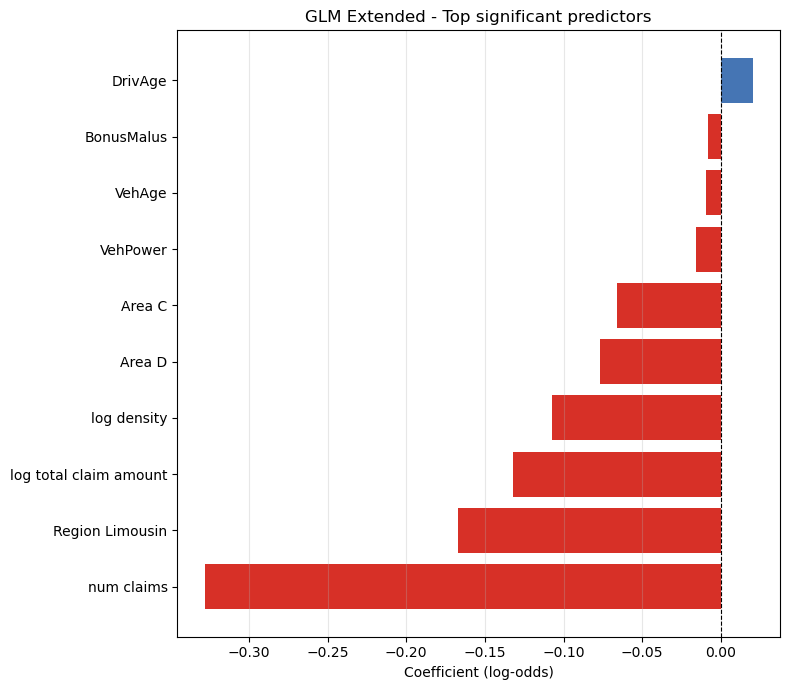

In [50]:
# Plots top 10 positive coefficients
top_pos = (
    glm_coef[glm_coef['significant']]
    .sort_values('coefficient', ascending=False)
    .head(10)
)

top_neg = (
    glm_coef[glm_coef['significant']]
    .sort_values('coefficient', ascending=True)
    .head(10)
)

plot_df = pd.concat([top_neg, top_pos]).sort_values('coefficient')
plot_df['label'] = plot_df['feature'].str.replace('_', ' ', regex=False)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#d73027' if c < 0 else '#4575b4' for c in plot_df['coefficient']]

ax.barh(plot_df['label'], plot_df['coefficient'], color=colors)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('GLM Extended - Top significant predictors')
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

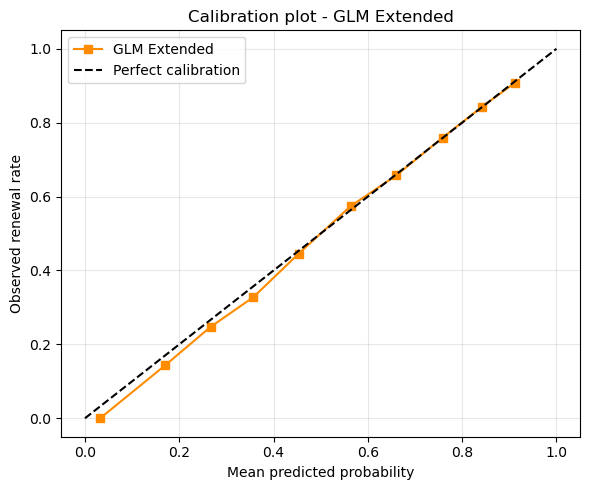

In [51]:
# Assesses probability calibration for extended GLM model
fig, ax = plt.subplots(figsize=(6, 5))

frac_pos, mean_pred = calibration_curve(y_ext_test, y_prob_ext_glm, n_bins=10)
ax.plot(mean_pred, frac_pos, 's-', color='darkorange', label='GLM Extended')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed renewal rate')
ax.set_title('Calibration plot - GLM Extended')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
# Summary statistics of number of observations in train and test data
#print("Training rows:", len(glm_train_df))
#print("Test rows:", len(glm_test_df))

#print("Baseline predictors:", x_base_train.shape[1] - 1)  # -1 for the index column
#print("Extended predictors:", x_ext_train.shape[1] - 1)

# Exploratory summaries

#print(glm_ext_result.summary())
#print(glm_coef.sort_values('coefficient', ascending=False))
#print(f"Total predictors: {len(glm_coef)}")
#print(f"Statistically significant (p < 0.05): {glm_coef['significant'].sum()}")
#print(lr_glm_comparison.round(4))
#print(glm_comparison_table.round(4))


## Applying the Random Forest Models

In [53]:
# The same train-test split is used
rf_train_df = function_model.loc[train_index].copy()
rf_test_df = function_model.loc[test_index].copy()

In [54]:
# Creates Random Forest predictor matrices
rf_x_train = rf_train_df[glm_claims_num_features + glm_cat_features].copy()
rf_x_test = rf_test_df[glm_claims_num_features + glm_cat_features].copy()

rf_y_train = rf_train_df["renewal"].copy()
rf_y_test = rf_test_df["renewal"].copy()

In [55]:
# Numerical preprocessing
rf_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical variables preprocessing
rf_cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [56]:
# Builds Random Forest model with balanced class weighting and:
# min node size = 50
# max tree depth = 12
# number of trees = 150

rf_preprocessor = ColumnTransformer(transformers=[
    ("num", rf_num_transformer, glm_claims_num_features),
    ("cat", rf_cat_transformer, glm_cat_features)
])

rf_model = Pipeline(steps=[
    ("preprocessor", rf_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=50,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

In [57]:
# Fits Random Forest model on the training data
rf_model.fit(rf_x_train, rf_y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Exposure', 'VehPower',
                                                   'VehAge', 'DrivAge',
                                                   'BonusMalus', 'num_claims',
                                                   'log_density',
                                                   'log_total_claim_amount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['VehBrand', 'VehGas', 'Area',
                                                   'Region'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=12, min_samples_leaf=50,
                                        n_estimators=150, n_jobs=-1,
                                        random_state=42))])

In [58]:
# Generates predictive probabilities for the test set
y_prob_rf = rf_model.predict_proba(rf_x_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

In [59]:
# Extracts feature importances
feature_names_rf = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances_rf = rf_model.named_steps["classifier"].feature_importances_

rf_importance = pd.DataFrame({
    "feature": feature_names_rf,
    "importance": importances_rf
}).sort_values("importance", ascending=False)

In [60]:
# Groups the features into their variable groups
def collapse_rf_feature_name(feature_name, cat_features):
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")
    for col in cat_features:
        if feature_name.startswith(f"cat__{col}_"):
            return col
    return feature_name

rf_importance["variable"] = rf_importance["feature"].apply(
    lambda x: collapse_rf_feature_name(x, glm_cat_features)
)

rf_grouped_importance = (
    rf_importance
    .groupby("variable", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

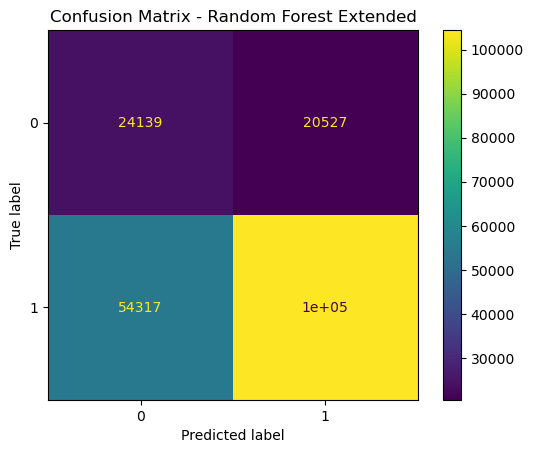

In [61]:
# Displays RF confusion matrix
ConfusionMatrixDisplay.from_predictions(rf_y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest Extended")
plt.show()

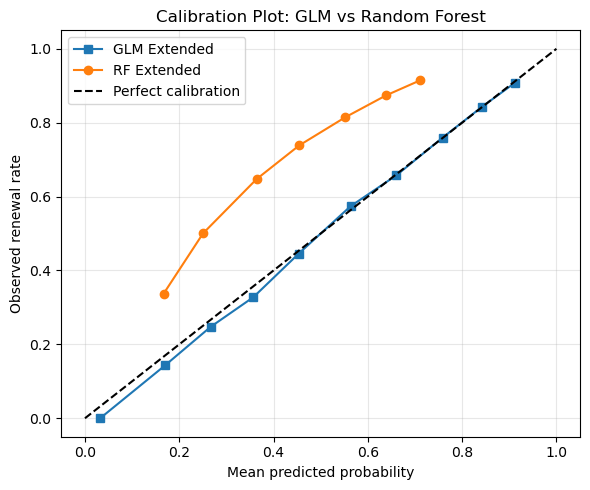

In [62]:
# Plots the calibration of GLM vs Random Forest
fig, ax = plt.subplots(figsize=(6, 5))

frac_pos_glm, mean_pred_glm = calibration_curve(y_ext_test, y_prob_ext_glm, n_bins=10)
frac_pos_rf, mean_pred_rf = calibration_curve(rf_y_test, y_prob_rf, n_bins=10)

ax.plot(mean_pred_glm, frac_pos_glm, marker="s", label="GLM Extended")
ax.plot(mean_pred_rf, frac_pos_rf, marker="o", label="RF Extended")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed renewal rate")
ax.set_title("Calibration Plot: GLM vs Random Forest")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

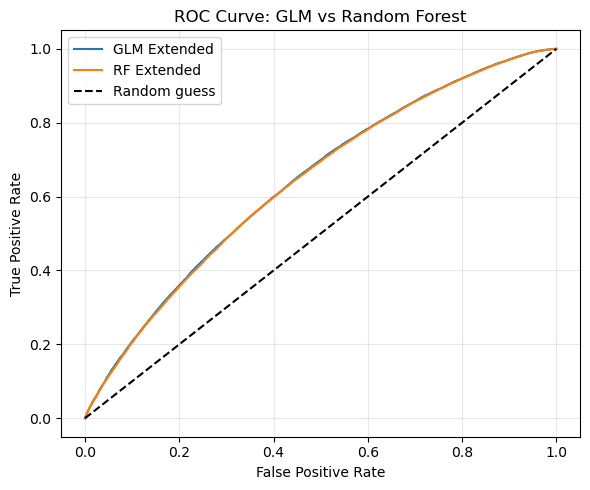

In [63]:
# Plots the ROC curves for the extended GLM and Random Forest models
fig, ax = plt.subplots(figsize=(6, 5))

fpr_glm, tpr_glm, _ = roc_curve(y_ext_test, y_prob_ext_glm)
fpr_rf, tpr_rf, _ = roc_curve(rf_y_test, y_prob_rf)

ax.plot(fpr_glm, tpr_glm, label="GLM Extended")
ax.plot(fpr_rf, tpr_rf, label="RF Extended")
ax.plot([0, 1], [0, 1], "k--", label="Random guess")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: GLM vs Random Forest")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

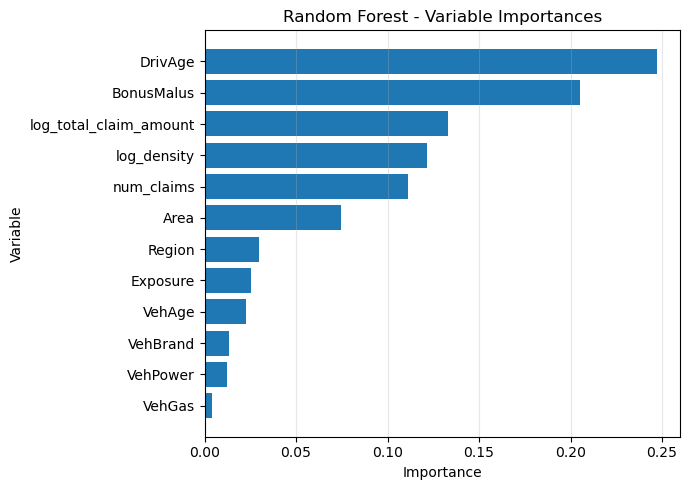

In [64]:
# Plots the grouped variables importances
fig, ax = plt.subplots(figsize=(7, 5))

top_vars = rf_grouped_importance.sort_values("importance")   # show all not top 10

ax.barh(top_vars["variable"], top_vars["importance"])
ax.set_xlabel("Importance")
ax.set_ylabel("Variable")
ax.set_title("Random Forest - Variable Importances")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
# Summary statistics 

#print(rf_grouped_importance)
#print(rf_importance)
#print(lr_glm_rf_comparison)
#print(rf_results)
#print("Accuracy:", round(accuracy_score(rf_y_test, y_pred_rf), 4))
#print("Balanced Accuracy:", round(balanced_accuracy_score(rf_y_test, y_pred_rf), 4))
#print("ROC-AUC:", round(roc_auc_score(rf_y_test, y_prob_rf), 4))
#print("Brier Score:", round(brier_score_loss(rf_y_test, y_prob_rf), 4))

#print("\nConfusion Matrix:\n", confusion_matrix(rf_y_test, y_pred_rf))
#print("\nClassification Report:\n", classification_report(rf_y_test, y_pred_rf, zero_division=0))
#print("Training rows:", len(rf_train_df))
#print("Test rows:", len(rf_test_df))

## Appendix Outputs

#### Full tables and summaries are uploaded to a folder called 'Outputs' 

In [66]:
# Creates new folder to store full tables and summaries
appendix_dir = "Outputs"
os.makedirs(appendix_dir, exist_ok=True)

In [67]:
# freMTPL2freq summary table
freq_summary = pd.DataFrame({
    "Variable": pols.columns,
    "Data Type": [str(pols[col].dtype) for col in pols.columns],
    "Non-Missing Count": [pols[col].notna().sum() for col in pols.columns],
    "Missing Count": [pols[col].isna().sum() for col in pols.columns],
    "Unique Values": [pols[col].nunique(dropna=True) for col in pols.columns]
})

freq_summary.to_csv(f"{appendix_dir}/freq_variable_summary.csv", index=False)

In [68]:
# freMTPL2sev summary table
sev_summary = pd.DataFrame({
    "Variable": claims.columns,
    "Data Type": [str(claims[col].dtype) for col in claims.columns],
    "Non-Missing Count": [claims[col].notna().sum() for col in claims.columns],
    "Missing Count": [claims[col].isna().sum() for col in claims.columns],
    "Unique Values": [claims[col].nunique(dropna=True) for col in claims.columns]
})

sev_summary.to_csv(f"{appendix_dir}/sev_variable_summary.csv", index=False)

In [69]:
# engineered variables summary table
engineered_vars = ["num_claims", "total_claim_amount", "avg_claim_amount", "has_claimed", "claim_frequency"]

engineered_summary = merged[engineered_vars].describe().T
engineered_summary["missing_count"] = merged[engineered_vars].isna().sum()
engineered_summary["zero_count"] = (merged[engineered_vars] == 0).sum()
engineered_summary = engineered_summary[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "missing_count", "zero_count"]
].round(4)

engineered_summary.to_csv(f"{appendix_dir}/engineered_variable_summary.csv")

In [70]:
# simulation design summary table
simulation_design = pd.DataFrame([
    {
        "Component": "has_claimed",
        "Code Form": 'merged["has_claimed"].fillna(0)',
        "Transformation / Scaling": "Binary indicator, missing values set to 0",
        "Weight in Score": -0.60,
        "Purpose": "Reduces renewal propensity for policies with prior claims"
    },
    {
        "Component": "num_claims",
        "Code Form": 'merged["num_claims"].clip(upper=3)',
        "Transformation / Scaling": "Capped at 3",
        "Weight in Score": -0.35,
        "Purpose": "Reduces renewal propensity as claim count increases, while limiting outlier influence"
    },
    {
        "Component": "total_claim_amount",
        "Code Form": 'np.log1p(merged["total_claim_amount"] / 1000)',
        "Transformation / Scaling": "log(1 + claim amount / 1000)",
        "Weight in Score": -0.35,
        "Purpose": "Captures claims severity with reduced skewness"
    },
    {
        "Component": "BonusMalus",
        "Code Form": '(merged["BonusMalus"] - 100) / 50',
        "Transformation / Scaling": "Centred at 100 and scaled by 50",
        "Weight in Score": -0.40,
        "Purpose": "Represents prior claims/risk experience on a stable scale"
    },
    {
        "Component": "DrivAge",
        "Code Form": '(merged["DrivAge"] - 40) / 10',
        "Transformation / Scaling": "Centred at 40 and scaled by 10",
        "Weight in Score": 0.20,
        "Purpose": "Allows older drivers to have slightly higher renewal propensity"
    },
    {
        "Component": "VehAge",
        "Code Form": 'merged["VehAge"] / 10',
        "Transformation / Scaling": "Scaled by 10",
        "Weight in Score": -0.10,
        "Purpose": "Allows older vehicles to slightly reduce renewal propensity"
    },
    {
        "Component": "VehPower",
        "Code Form": '(merged["VehPower"] - 5) / 5',
        "Transformation / Scaling": "Centred at 5 and scaled by 5",
        "Weight in Score": -0.08,
        "Purpose": "Introduces a mild reduction in renewal propensity for higher-power vehicles"
    },
    {
        "Component": "Density",
        "Code Form": 'np.log1p(merged["Density"])',
        "Transformation / Scaling": "log(1 + Density)",
        "Weight in Score": -0.10,
        "Purpose": "Allows denser areas to reduce renewal propensity without extreme values dominating"
    },
    {
        "Component": "Area",
        "Code Form": 'merged["Area"].map(area_map).fillna(0)',
        "Transformation / Scaling": "Mapped category effect",
        "Weight in Score": 1.00,
        "Purpose": "Introduces a simple geographical gradient in renewal propensity"
    }
])

simulation_design.to_csv(f"{appendix_dir}/simulation_design_table.csv", index=False)

In [71]:
# simulation summary table
simulation_summary = pd.DataFrame({
    "Measure": [
        "Target Retention Rate",
        "Achieved Retention Rate",
        "Mean Renewal Probability - No Claim Policies",
        "Mean Renewal Probability - Claim Policies",
        "Mean Renewal Outcome - No Claim Policies",
        "Mean Renewal Outcome - Claim Policies",
        "Calibrated Intercept"
    ],
    "Value": [
        target_retention,
        merged["renewal"].mean(),
        merged.loc[merged["has_claimed"] == 0, "renewal_prob"].mean(),
        merged.loc[merged["has_claimed"] == 1, "renewal_prob"].mean(),
        merged.loc[merged["has_claimed"] == 0, "renewal"].mean(),
        merged.loc[merged["has_claimed"] == 1, "renewal"].mean(),
        intercept
    ]
}).round(6)

simulation_summary.to_csv(f"{appendix_dir}/simulation_summary_table.csv", index=False)

In [72]:
# simulation inputs table
simulation_input_summary = pd.DataFrame({
    "raw_num_claims": merged["num_claims"].describe(),
    "capped_num_claims": num_claims.describe(),
    "raw_total_claim_amount": merged["total_claim_amount"].describe(),
    "log_claim_cost_k": log_claim_cost_k.describe(),
    "BonusMalus_scaled": bm.describe(),
    "driver_age_scaled": driver_age.describe(),
    "veh_age_scaled": veh_age.describe(),
    "veh_power_scaled": veh_power.describe(),
    "log_density": log_density.describe()
}).round(4).T

simulation_input_summary.to_csv(f"{appendix_dir}/simulation_input_distribution_summary.csv")

In [73]:
def run_logistic_pipeline_detailed(x, y, num_features, cat_features):
    x_train, x_test, y_train, y_test = train_test_split(
        x[num_features + cat_features],
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    num_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ])

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ])

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    return model, x_train, x_test, y_train, y_test, y_pred, y_prob


# rerun baseline and extended LR with full outputs
lr_base_model, lr_base_x_train, lr_base_x_test, lr_base_y_train, lr_base_y_test, lr_base_y_pred, lr_base_y_prob = run_logistic_pipeline_detailed(
    x=function_model,
    y=y_function,
    num_features=baseline_num_features,
    cat_features=cat_features
)

lr_ext_model, lr_ext_x_train, lr_ext_x_test, lr_ext_y_train, lr_ext_y_test, lr_ext_y_pred, lr_ext_y_prob = run_logistic_pipeline_detailed(
    x=function_model,
    y=y_function,
    num_features=claims_num_features,
    cat_features=cat_features
)

In [74]:
# logistic regression performance table
lr_performance_table = pd.DataFrame([
    {
        "Model": "LR Baseline",
        "Accuracy": accuracy_score(lr_base_y_test, lr_base_y_pred),
        "ROC-AUC": roc_auc_score(lr_base_y_test, lr_base_y_prob),
        "Brier Score": brier_score_loss(lr_base_y_test, lr_base_y_prob)
    },
    {
        "Model": "LR Extended",
        "Accuracy": accuracy_score(lr_ext_y_test, lr_ext_y_pred),
        "ROC-AUC": roc_auc_score(lr_ext_y_test, lr_ext_y_prob),
        "Brier Score": brier_score_loss(lr_ext_y_test, lr_ext_y_prob)
    }
]).round(4)

lr_performance_table.to_csv(f"{appendix_dir}/lr_performance_table.csv", index=False)

In [75]:
# logistic regression extended and baseline confusion matrices
lr_base_cm = pd.DataFrame(
    confusion_matrix(lr_base_y_test, lr_base_y_pred),
    index=["Observed Non-renewal", "Observed Renewal"],
    columns=["Predicted Non-renewal", "Predicted Renewal"]
)

lr_ext_cm = pd.DataFrame(
    confusion_matrix(lr_ext_y_test, lr_ext_y_pred),
    index=["Observed Non-renewal", "Observed Renewal"],
    columns=["Predicted Non-renewal", "Predicted Renewal"]
)

lr_base_cm.to_csv(f"{appendix_dir}/lr_baseline_confusion_matrix.csv")
lr_ext_cm.to_csv(f"{appendix_dir}/lr_extended_confusion_matrix.csv")

In [76]:
# logistic regression extended and baseline classification reports
lr_base_report = pd.DataFrame(classification_report(
    lr_base_y_test, lr_base_y_pred, output_dict=True
)).T.round(4)

lr_ext_report = pd.DataFrame(classification_report(
    lr_ext_y_test, lr_ext_y_pred, output_dict=True
)).T.round(4)

lr_base_report.to_csv(f"{appendix_dir}/lr_baseline_classification_report.csv")
lr_ext_report.to_csv(f"{appendix_dir}/lr_extended_classification_report.csv")

In [77]:
def extract_lr_coefficients(pipeline_model):
    feature_names = pipeline_model.named_steps["preprocessor"].get_feature_names_out()
    coefficients = pipeline_model.named_steps["classifier"].coef_[0]

    coef_table = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients,
        "odds_ratio": np.exp(coefficients)
    }).sort_values("coefficient", ascending=False)

    return coef_table

lr_base_coef = extract_lr_coefficients(lr_base_model).round(6)
lr_ext_coef = extract_lr_coefficients(lr_ext_model).round(6)

lr_base_coef.to_csv(f"{appendix_dir}/lr_baseline_coefficients.csv", index=False)
lr_ext_coef.to_csv(f"{appendix_dir}/lr_extended_coefficients.csv", index=False)

lr_base_coef.head(), lr_ext_coef.head()

(                             feature  coefficient  odds_ratio
 3                       num__DrivAge     0.271387    1.311783
 34  cat__Region_Languedoc-Roussillon     0.026167    1.026512
 17               cat__VehGas_Regular     0.017971    1.018134
 13                  cat__VehBrand_B3     0.017662    1.017819
 16                  cat__VehBrand_B6     0.016389    1.016524,
                              feature  coefficient  odds_ratio
 3                       num__DrivAge     0.284909    1.329640
 39  cat__Region_Languedoc-Roussillon     0.030711    1.031188
 44              cat__Region_Picardie     0.027713    1.028101
 13                 cat__VehBrand_B11     0.027171    1.027544
 35                 cat__Region_Corse     0.023477    1.023755)

In [78]:
# GLM fit statistics 
glm_fit_table = pd.DataFrame([
    {
        "Model": "GLM Baseline",
        "Null Deviance": glm_base_result.null_deviance,
        "Residual Deviance": glm_base_result.deviance,
        "Deviance Reduction (%)": (glm_base_result.null_deviance - glm_base_result.deviance) / glm_base_result.null_deviance * 100,
        "AIC": glm_base_result.aic,
        "Df Residuals": glm_base_result.df_resid
    },
    {
        "Model": "GLM Extended",
        "Null Deviance": glm_ext_result.null_deviance,
        "Residual Deviance": glm_ext_result.deviance,
        "Deviance Reduction (%)": (glm_ext_result.null_deviance - glm_ext_result.deviance) / glm_ext_result.null_deviance * 100,
        "AIC": glm_ext_result.aic,
        "Df Residuals": glm_ext_result.df_resid
    }
]).round(4)

glm_fit_table.to_csv(f"{appendix_dir}/glm_fit_statistics.csv", index=False)

In [79]:
# GLM performance table
glm_performance_table = pd.DataFrame([
    {
        "Model": "GLM Baseline",
        "Accuracy": accuracy_score(y_base_test, y_pred_base_glm),
        "ROC-AUC": roc_auc_score(y_base_test, y_prob_base_glm),
        "Brier Score": brier_score_loss(y_base_test, y_prob_base_glm)
    },
    {
        "Model": "GLM Extended",
        "Accuracy": accuracy_score(y_ext_test, y_pred_ext_glm),
        "ROC-AUC": roc_auc_score(y_ext_test, y_prob_ext_glm),
        "Brier Score": brier_score_loss(y_ext_test, y_prob_ext_glm)
    }
]).round(4)

glm_performance_table.to_csv(f"{appendix_dir}/glm_performance_table.csv", index=False)

In [80]:
# GLM baseline and extended model confusion matrices
glm_base_cm = pd.DataFrame(
    confusion_matrix(y_base_test, y_pred_base_glm),
    index=["Observed Non-renewal", "Observed Renewal"],
    columns=["Predicted Non-renewal", "Predicted Renewal"]
)

glm_ext_cm = pd.DataFrame(
    confusion_matrix(y_ext_test, y_pred_ext_glm),
    index=["Observed Non-renewal", "Observed Renewal"],
    columns=["Predicted Non-renewal", "Predicted Renewal"]
)

glm_base_cm.to_csv(f"{appendix_dir}/glm_baseline_confusion_matrix.csv")
glm_ext_cm.to_csv(f"{appendix_dir}/glm_extended_confusion_matrix.csv")

In [81]:
# GLM baseline and extended model classification reports
glm_base_report = pd.DataFrame(classification_report(
    y_base_test, y_pred_base_glm, output_dict=True
)).T.round(4)

glm_ext_report = pd.DataFrame(classification_report(
    y_ext_test, y_pred_ext_glm, output_dict=True
)).T.round(4)

glm_base_report.to_csv(f"{appendix_dir}/glm_baseline_classification_report.csv")
glm_ext_report.to_csv(f"{appendix_dir}/glm_extended_classification_report.csv")

In [82]:
# GLM baseline and extended model coefficient tables
glm_base_coef = pd.DataFrame({
    "feature": glm_base_result.params.index,
    "coefficient": glm_base_result.params.values,
    "std_err": glm_base_result.bse.values,
    "z_stat": glm_base_result.tvalues.values,
    "p_value": glm_base_result.pvalues.values,
    "odds_ratio": np.exp(glm_base_result.params.values)
}).round(6)

glm_ext_coef_full = pd.DataFrame({
    "feature": glm_ext_result.params.index,
    "coefficient": glm_ext_result.params.values,
    "std_err": glm_ext_result.bse.values,
    "z_stat": glm_ext_result.tvalues.values,
    "p_value": glm_ext_result.pvalues.values,
    "odds_ratio": np.exp(glm_ext_result.params.values)
}).round(6)

glm_base_coef.to_csv(f"{appendix_dir}/glm_baseline_coefficients.csv", index=False)
glm_ext_coef_full.to_csv(f"{appendix_dir}/glm_extended_coefficients.csv", index=False)

In [83]:
with open(f"{appendix_dir}/glm_baseline_summary.txt", "w") as f:
    f.write(str(glm_base_result.summary()))

with open(f"{appendix_dir}/glm_extended_summary.txt", "w") as f:
    f.write(str(glm_ext_result.summary()))

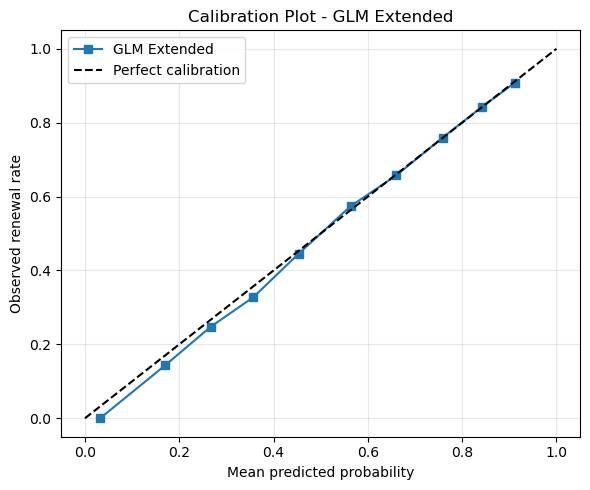

In [84]:
fig, ax = plt.subplots(figsize=(6, 5))

frac_pos, mean_pred = calibration_curve(y_ext_test, y_prob_ext_glm, n_bins=10)
ax.plot(mean_pred, frac_pos, marker="s", label="GLM Extended")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed renewal rate")
ax.set_title("Calibration Plot - GLM Extended")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{appendix_dir}/glm_calibration_plot.png", dpi=300, bbox_inches="tight")

In [85]:
# Random Forest parameter table
rf_parameter_table = pd.DataFrame(
    list(rf_model.named_steps["classifier"].get_params().items()),
    columns=["Parameter", "Value"]
)

rf_parameter_table.to_csv(f"{appendix_dir}/rf_parameter_table.csv", index=False)

In [86]:
# Random Forest performance table
rf_performance_table = pd.DataFrame([{
    "Model": "Random Forest Extended",
    "Accuracy": accuracy_score(rf_y_test, y_pred_rf),
    "Balanced Accuracy": balanced_accuracy_score(rf_y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(rf_y_test, y_prob_rf),
    "Brier Score": brier_score_loss(rf_y_test, y_prob_rf)
}]).round(4)

rf_performance_table.to_csv(f"{appendix_dir}/rf_performance_table.csv", index=False)

In [87]:
# Random Forest confusion matrix and classification report
rf_cm = pd.DataFrame(
    confusion_matrix(rf_y_test, y_pred_rf),
    index=["Observed Non-renewal", "Observed Renewal"],
    columns=["Predicted Non-renewal", "Predicted Renewal"]
)

rf_report = pd.DataFrame(classification_report(
    rf_y_test, y_pred_rf, output_dict=True
)).T.round(4)

rf_cm.to_csv(f"{appendix_dir}/rf_confusion_matrix.csv")
rf_report.to_csv(f"{appendix_dir}/rf_classification_report.csv")

In [88]:
# Random Forest variable importance tables
rf_importance.to_csv(f"{appendix_dir}/rf_ungrouped_feature_importance.csv", index=False)
rf_grouped_importance.to_csv(f"{appendix_dir}/rf_grouped_feature_importance.csv", index=False)

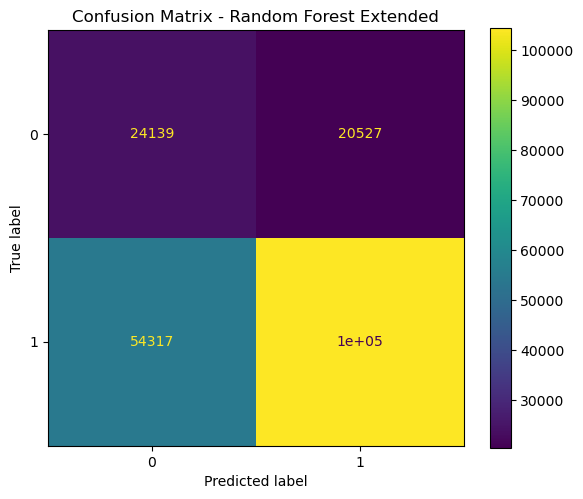

In [89]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(rf_y_test, y_pred_rf, ax=ax)
ax.set_title("Confusion Matrix - Random Forest Extended")
plt.tight_layout()
plt.savefig(f"{appendix_dir}/rf_confusion_matrix_plot.png", dpi=300, bbox_inches="tight")

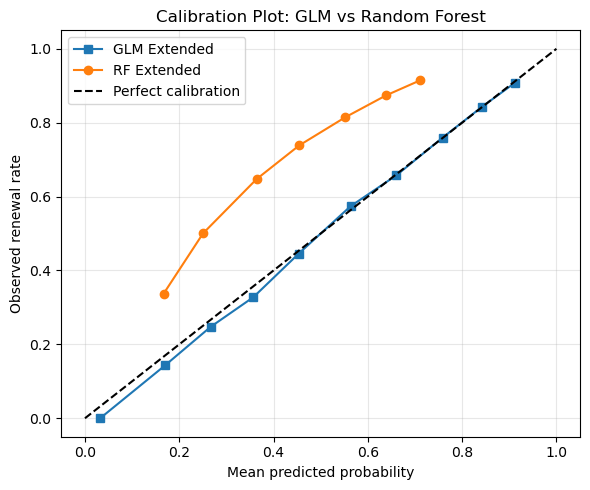

In [90]:
fig, ax = plt.subplots(figsize=(6, 5))

frac_pos_glm, mean_pred_glm = calibration_curve(y_ext_test, y_prob_ext_glm, n_bins=10)
frac_pos_rf, mean_pred_rf = calibration_curve(rf_y_test, y_prob_rf, n_bins=10)

ax.plot(mean_pred_glm, frac_pos_glm, marker="s", label="GLM Extended")
ax.plot(mean_pred_rf, frac_pos_rf, marker="o", label="RF Extended")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed renewal rate")
ax.set_title("Calibration Plot: GLM vs Random Forest")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{appendix_dir}/glm_vs_rf_calibration_plot.png", dpi=300, bbox_inches="tight")
plt.show()

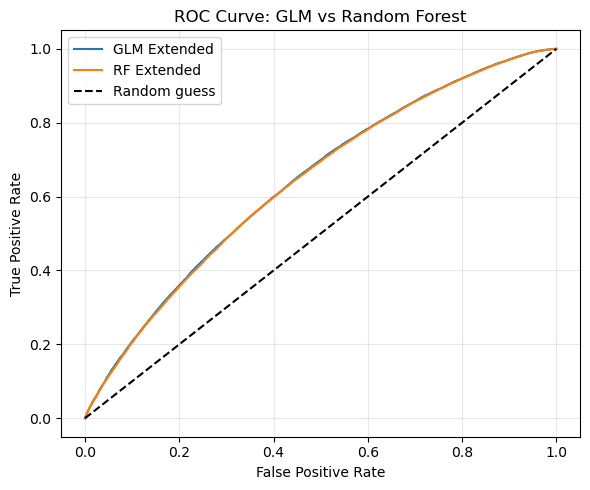

In [91]:
fig, ax = plt.subplots(figsize=(6, 5))

fpr_glm, tpr_glm, _ = roc_curve(y_ext_test, y_prob_ext_glm)
fpr_rf, tpr_rf, _ = roc_curve(rf_y_test, y_prob_rf)

ax.plot(fpr_glm, tpr_glm, label="GLM Extended")
ax.plot(fpr_rf, tpr_rf, label="RF Extended")
ax.plot([0, 1], [0, 1], "k--", label="Random guess")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: GLM vs Random Forest")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{appendix_dir}/roc_comparison_plot.png", dpi=300, bbox_inches="tight")
plt.show()

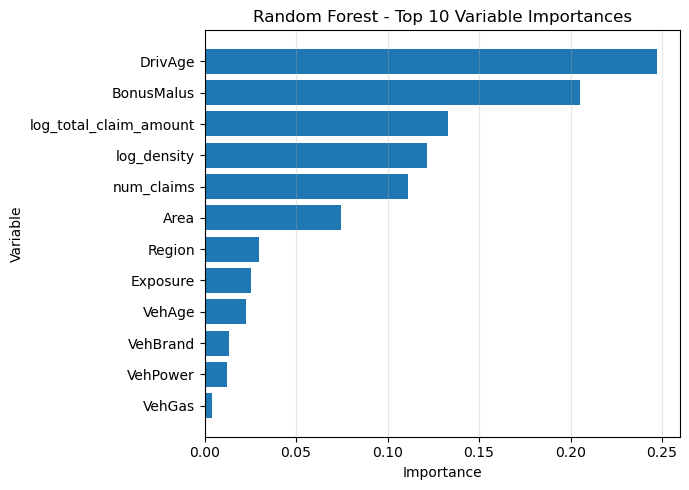

In [92]:
fig, ax = plt.subplots(figsize=(7, 5))

top_vars = rf_grouped_importance.sort_values("importance")

ax.barh(top_vars["variable"], top_vars["importance"])
ax.set_xlabel("Importance")
ax.set_ylabel("Variable")
ax.set_title("Random Forest - Top 10 Variable Importances")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{appendix_dir}/rf_grouped_importance_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [93]:
# Comparison table of all models
all_model_comparison = pd.DataFrame([
    {
        "Model": "LR Baseline",
        "Accuracy": accuracy_score(lr_base_y_test, lr_base_y_pred),
        "ROC-AUC": roc_auc_score(lr_base_y_test, lr_base_y_prob),
        "Brier Score": brier_score_loss(lr_base_y_test, lr_base_y_prob)
    },
    {
        "Model": "LR Extended",
        "Accuracy": accuracy_score(lr_ext_y_test, lr_ext_y_pred),
        "ROC-AUC": roc_auc_score(lr_ext_y_test, lr_ext_y_prob),
        "Brier Score": brier_score_loss(lr_ext_y_test, lr_ext_y_prob)
    },
    {
        "Model": "GLM Baseline",
        "Accuracy": accuracy_score(y_base_test, y_pred_base_glm),
        "ROC-AUC": roc_auc_score(y_base_test, y_prob_base_glm),
        "Brier Score": brier_score_loss(y_base_test, y_prob_base_glm)
    },
    {
        "Model": "GLM Extended",
        "Accuracy": accuracy_score(y_ext_test, y_pred_ext_glm),
        "ROC-AUC": roc_auc_score(y_ext_test, y_prob_ext_glm),
        "Brier Score": brier_score_loss(y_ext_test, y_prob_ext_glm)
    },
    {
        "Model": "Random Forest Extended",
        "Accuracy": accuracy_score(rf_y_test, y_pred_rf),
        "Balanced Accuracy": balanced_accuracy_score(rf_y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(rf_y_test, y_prob_rf),
        "Brier Score": brier_score_loss(rf_y_test, y_prob_rf)
    }
]).round(4)

all_model_comparison.to_csv(f"{appendix_dir}/all_model_comparison_table.csv", index=False)